<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/IMS_3rdtest_RtF_Detection_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMS 3rd_test — Run-to-Failure 조기탐지 (일반화 검증)

**트랙:** `onsite_r2f_ims/` (독립 노트북 — Paderborn/binary 트랙과 혼용 금지)

**목적:** 2nd_test(73.3h 리드타임) 성공에 이어, **완만한 열화 케이스**에서도 조기탐지가 일반화되는지 검증

| 항목 | 2nd_test | **3rd_test (이번)** |
|:---|:---:|:---:|
| 파일 수 | 984개 | ~6,324개 |
| 타깃 고장 | Bearing1 외륜 | **Bearing3 외륜** |
| 타깃 열 | 열0 | **열2** ← ★ 다름 |
| 열화 특성 | 막판 급폭발형 | **완만·점진형** |
| 샘플링 | 20,480 Hz | 20,480 Hz (동일) |
| 파일 구조 | 20,480×4, 탭, 헤더 없음 | 동일 |

> ⚠️ **가장 중요한 차이:** `TARGET_BEARING_COL = 2` (2nd의 0과 다름). 이걸 0으로 두면 엉뚱한 베어링을 분석함.

**실행 순서:** `A(폰트설치)` → **런타임재시작** → `A-2(폰트적용)` → `1` → `2` → `3` → `4` → `5` → `B` → `C` → `D`

**판정 목표:** 베이스라인 평평 + 후반 상승 + RMS/Kurtosis 동반 + 오경보 0건 + **리드타임 ≥ 2nd(73.3h)**

# ============================================================
# 셀 A — 한글 폰트 설치 (최초 1회만)
# 실행 후 반드시 런타임 재시작: 런타임 메뉴 > 세션 다시 시작
# ============================================================
!apt-get -qq install fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

import subprocess
result = subprocess.run(['ls', '/usr/share/fonts/truetype/nanum/'],
                        capture_output=True, text=True)
print('설치된 나눔폰트 파일:')
print(result.stdout)

print('=' * 50)
print('★ 여기서 런타임을 재시작해야 합니다 ★')
print('  Colab 메뉴: 런타임 > 세션 다시 시작')
print('  또는 단축키: Ctrl+M 다음 .')
print('  재시작 후 셀A-2부터 실행하세요')
print('=' * 50)

폰트 파일 확인: /usr/share/fonts/truetype/nanum/NanumGothic.ttf ✅
적용 폰트: ['NanumGothic']


/tmp/ipykernel_428/1451867549.py:22: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


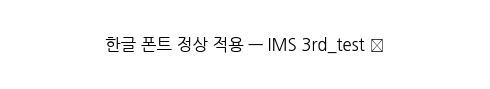

위 텍스트가 깨지지 않으면 OK → 셀1 진행


In [2]:
# ============================================================
# 셀 A-2 — 한글 폰트 적용 (런타임 재시작 후, 매번 실행)
# 그래프 그리는 모든 셀보다 먼저 실행해야 함
# ============================================================
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    print(f'폰트 파일 확인: {font_path} ✅')
    print(f'적용 폰트: {plt.rcParams["font.family"]}')
    # 한글 렌더링 테스트
    fig, ax = plt.subplots(figsize=(5, 1))
    ax.text(0.5, 0.5, '한글 폰트 정상 적용 — IMS 3rd_test ✅',
            ha='center', va='center', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()
    print('위 텍스트가 깨지지 않으면 OK → 셀1 진행')
else:
    print(f'폰트 파일 없음: {font_path}')
    print('셀A 먼저 실행 후 런타임 재시작하세요')

In [3]:
# ============================================================
# 셀 1 — 라이브러리 & 드라이브 마운트 & 경로 확인
# ============================================================
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.stats import kurtosis, skew
from scipy.signal import hilbert
from numpy.linalg import pinv

# 폰트 안전망 (셀A-2 없이 실행한 경우)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/IMS_NASA'

print('=== IMS_NASA 내부 폴더 구조 ===')
for root, dirs, files_in in os.walk(BASE):
    level = root.replace(BASE, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level >= 1:
        break

print()
print('[확인] 3rd_test 폴더 위치를 확인하세요.')
print('  BASE/3rd_test      → 셀2 TEST3_DIR 수정 불필요')
print('  BASE/3rd_test/3rd_test → 셀2 TEST3_DIR 한 겹 더 추가')

Mounted at /content/drive
=== IMS_NASA 내부 폴더 구조 ===
IMS_NASA/
  3rd_test/

[확인] 3rd_test 폴더 위치를 확인하세요.
  BASE/3rd_test      → 셀2 TEST3_DIR 수정 불필요
  BASE/3rd_test/3rd_test → 셀2 TEST3_DIR 한 겹 더 추가


In [4]:
# ============================================================
# 셀 2 — 파라미터 설정 & 파일 목록 로딩 & 구조 검증
# ★ 2nd_test와 다른 설정: TEST3_DIR, TARGET_BEARING_COL=2
# ============================================================

# ================= 사용자 설정 (3rd_test 전용) =================
TEST3_DIR          = BASE + '/3rd_test'   # ← 셀1 출력 보고 필요시 수정
FS                 = 20480                # 동일 (IMS 공식)
TARGET_BEARING_COL = 2                    # ★ Bearing3 = 열2 (2nd의 열0과 다름!)
BASELINE_RATIO     = 0.15                 # 초기 15%를 정상 베이스라인으로 등록
# ==============================================================

files = sorted(glob.glob(os.path.join(TEST3_DIR, '*')))
files = [f for f in files
         if re.match(r'.*\d{4}\.\d{2}\.\d{2}', os.path.basename(f))]

print(f'총 파일 수 : {len(files)}  (예상 ~6,324)')
print(f'첫  파일   : {os.path.basename(files[0])}')
print(f'마지막 파일: {os.path.basename(files[-1])}')

sample = np.loadtxt(files[0])
print(f'파일 shape : {sample.shape}  (예상 (20480, 4))')

assert len(files) > 0,           '파일을 찾을 수 없음 — TEST3_DIR 경로 확인'
assert sample.shape[0] == 20480, f'행 수 불일치: {sample.shape[0]} (예상 20480)'
assert sample.shape[1] == 4,     f'열 수 불일치: {sample.shape[1]} (예상 4)'

print()
print(f'타깃 채널: 열{TARGET_BEARING_COL} = Bearing{TARGET_BEARING_COL+1} (외륜 고장 타깃)')
print()

# ---- 타임스탬프 연속성 검사 (파일 혼재 여부 확인) ----
from datetime import datetime

def parse_ts(fname):
    base  = os.path.basename(fname)
    parts = base.split('.')
    if len(parts) >= 6:
        try:
            return datetime(int(parts[0]), int(parts[1]), int(parts[2]),
                            int(parts[3]), int(parts[4]), int(parts[5]))
        except Exception:
            pass
    return None

timestamps = [parse_ts(f) for f in files]
valid_ts   = [t for t in timestamps if t is not None]

if len(valid_ts) >= 2:
    t_start = valid_ts[0]
    t_end   = valid_ts[-1]
    total_h = (t_end - t_start).total_seconds() / 3600
    print(f'실험 시작: {t_start}')
    print(f'실험 종료: {t_end}')
    print(f'총 실험 시간: {total_h:.1f}시간')

    # 간격 이상치 탐지 (중간에 큰 점프가 있으면 파일 혼재 의심)
    gaps = []
    for i in range(1, min(len(valid_ts), 50)):
        g = (valid_ts[i] - valid_ts[i-1]).total_seconds() / 60
        gaps.append(g)
    if gaps:
        print(f'초반 파일 간격 — 평균: {np.mean(gaps):.1f}분, 최대: {max(gaps):.1f}분')
        if max(gaps) > 120:
            print('⚠️  120분 이상 점프 감지 — 중간에 다른 실험 파일이 섞였을 가능성 있음')
            print('   타임스탬프 전체 분포를 시각화(셀2-extra)로 확인 권장')
        else:
            print('파일 간격 정상 (혼재 없음)')
else:
    print('타임스탬프 파싱 불가 — 파일명 형식 확인 필요')

print()
print('✅ shape 검증 통과 — 셀3으로 진행하세요')

총 파일 수 : 6324  (예상 ~6,324)
첫  파일   : 2004.03.04.09.27.46
마지막 파일: 2004.04.18.02.42.55
파일 shape : (20480, 4)  (예상 (20480, 4))

타깃 채널: 열2 = Bearing3 (외륜 고장 타깃)

실험 시작: 2004-03-04 09:27:46
실험 종료: 2004-04-18 02:42:55
총 실험 시간: 1073.3시간
초반 파일 간격 — 평균: 9.9분, 최대: 10.0분
파일 간격 정상 (혼재 없음)

✅ shape 검증 통과 — 셀3으로 진행하세요


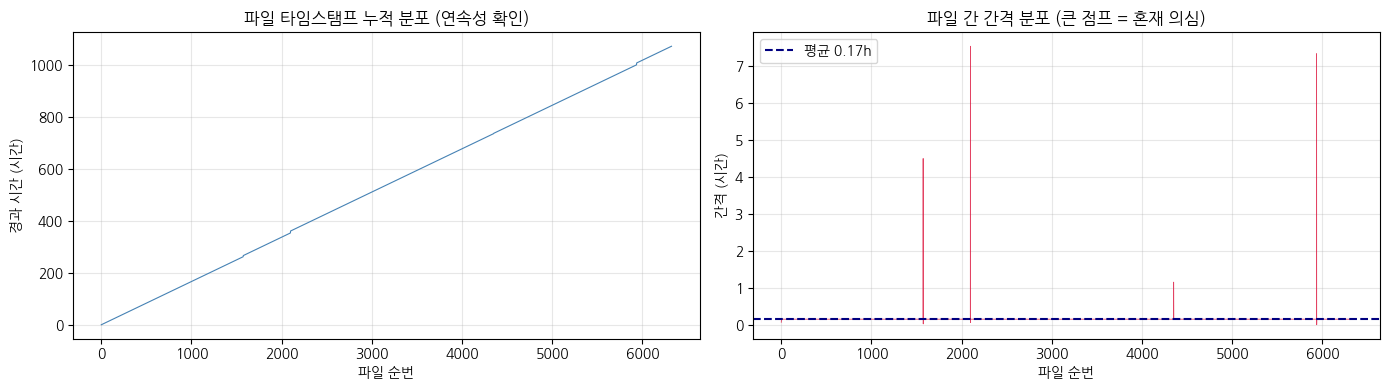

[주의] 2.0h 초과 점프 3건:
  파일 #1573→#1574: 4.50h 점프
  파일 #2097→#2098: 7.53h 점프
  파일 #5935→#5936: 7.33h 점프


In [5]:
# ============================================================
# 셀 2-extra — 타임스탬프 분포 시각화 (선택)
# 파일 혼재 의심 시 실행. 정상이면 건너뜀.
# ============================================================

t_ref   = valid_ts[0]
elapsed = [(t - t_ref).total_seconds() / 3600 for t in valid_ts]

# 파일 간격 분포
gaps_all = [elapsed[i] - elapsed[i-1] for i in range(1, len(elapsed))]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(elapsed, color='steelblue', lw=0.8)
axes[0].set_title('파일 타임스탬프 누적 분포 (연속성 확인)')
axes[0].set_xlabel('파일 순번')
axes[0].set_ylabel('경과 시간 (시간)')
axes[0].grid(alpha=0.3)

axes[1].plot(gaps_all, color='crimson', lw=0.6, alpha=0.8)
axes[1].axhline(np.mean(gaps_all), color='navy', ls='--', label=f'평균 {np.mean(gaps_all):.2f}h')
axes[1].set_title('파일 간 간격 분포 (큰 점프 = 혼재 의심)')
axes[1].set_xlabel('파일 순번')
axes[1].set_ylabel('간격 (시간)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 큰 점프 위치 출력
threshold_gap = 2.0  # 2시간 이상 점프를 이상치로 판정
big_gaps = [(i, g) for i, g in enumerate(gaps_all) if g > threshold_gap]
if big_gaps:
    print(f'[주의] {threshold_gap}h 초과 점프 {len(big_gaps)}건:')
    for idx, gap in big_gaps[:10]:
        print(f'  파일 #{idx}→#{idx+1}: {gap:.2f}h 점프')
else:
    print(f'큰 점프 없음 (>{threshold_gap}h 기준) — 파일 연속성 정상')

In [6]:
# ============================================================
# 셀 3 — 물리 특징 추출 전 구간
# 3rd_test는 ~6,324개로 2nd보다 6배 이상 많음 → 상당히 오래 걸림
# GPU 런타임으로 전환하면 빠름 (Colab: 런타임 > 런타임 유형 변경)
# ============================================================

def extract_features(sig, fs=FS):
    """1초 진동 신호(20480점) → 물리 특징 벡터 9개."""
    x = sig.astype(np.float64)

    rms   = np.sqrt(np.mean(x**2))
    peak  = np.max(np.abs(x))
    crest = peak / (rms + 1e-12)
    kurt  = kurtosis(x)
    sk    = skew(x)
    p2p   = np.ptp(x)
    std   = np.std(x)

    env     = np.abs(hilbert(x))
    env_rms = np.sqrt(np.mean((env - env.mean())**2))

    fft_mag   = np.abs(np.fft.rfft(x))
    freqs     = np.fft.rfftfreq(len(x), 1/fs)
    hf_energy = np.sum(fft_mag[freqs > 2000]**2) / (np.sum(fft_mag**2) + 1e-12)

    return np.array([rms, peak, crest, kurt, sk, p2p, std, env_rms, hf_energy])

FEATURE_NAMES = ['RMS', 'Peak', 'Crest', 'Kurtosis', 'Skew',
                 'P2P', 'Std', 'EnvRMS', 'HF_ratio']

print(f'Bearing3(열{TARGET_BEARING_COL}) 특징 추출 시작 — {len(files)}개 파일...')
print('(파일 수가 많아 수십 분 걸릴 수 있습니다)')

feats = []
for i, f in enumerate(files):
    data = np.loadtxt(f)
    sig  = data[:, TARGET_BEARING_COL]
    feats.append(extract_features(sig))
    if i % 500 == 0:
        print(f'  {i}/{len(files)} 완료... ({i/len(files)*100:.1f}%)')

feats = np.array(feats)
print()
print(f'✅ 특징 행렬 shape: {feats.shape}  (파일수 × 9)')

Bearing3(열2) 특징 추출 시작 — 6324개 파일...
(파일 수가 많아 수십 분 걸릴 수 있습니다)
  0/6324 완료... (0.0%)
  500/6324 완료... (7.9%)
  1000/6324 완료... (15.8%)
  1500/6324 완료... (23.7%)
  2000/6324 완료... (31.6%)
  2500/6324 완료... (39.5%)
  3000/6324 완료... (47.4%)
  3500/6324 완료... (55.3%)
  4000/6324 완료... (63.3%)
  4500/6324 완료... (71.2%)
  5000/6324 완료... (79.1%)
  5500/6324 완료... (87.0%)
  6000/6324 완료... (94.9%)

✅ 특징 행렬 shape: (6324, 9)  (파일수 × 9)


In [7]:
# ============================================================
# 셀 4 — 베이스라인 등록 & Mahalanobis 이탈 탐지
# ============================================================

n_base   = int(len(feats) * BASELINE_RATIO)
baseline = feats[:n_base]
print(f'베이스라인 등록: 초기 {n_base}개 파일 (전체의 {BASELINE_RATIO*100:.0f}%)')

mu      = baseline.mean(axis=0)
sigma   = baseline.std(axis=0) + 1e-12
base_n  = (baseline - mu) / sigma
feats_n = (feats    - mu) / sigma

cov_inv  = pinv(np.cov(base_n.T))
mean_vec = base_n.mean(axis=0)

def mahalanobis(v):
    d = v - mean_vec
    return np.sqrt(d @ cov_inv @ d.T)

md = np.array([mahalanobis(v) for v in feats_n])

base_md   = md[:n_base]
threshold = base_md.mean() + 3 * base_md.std()
print(f'이탈 임계값 (mean+3std): {threshold:.3f}')

alarm_idx = None
for i in range(n_base, len(md) - 5):
    if np.all(md[i:i+5] > threshold):
        alarm_idx = i
        break

print()
if alarm_idx is not None:
    lead = len(md) - alarm_idx
    print(f'[조기탐지 성공] 파일 #{alarm_idx} — {os.path.basename(files[alarm_idx])}')
    print(f'  수명 소진율 : {alarm_idx/len(md)*100:.1f}%')
    print(f'  리드타임    : {lead}개 파일')
else:
    print('[경보 없음] → 셀 B 튜닝 표로 임계 조정하세요')

베이스라인 등록: 초기 948개 파일 (전체의 15%)
이탈 임계값 (mean+3std): 6.605

[조기탐지 성공] 파일 #5945 — 2004.04.15.11.42.55
  수명 소진율 : 94.0%
  리드타임    : 379개 파일


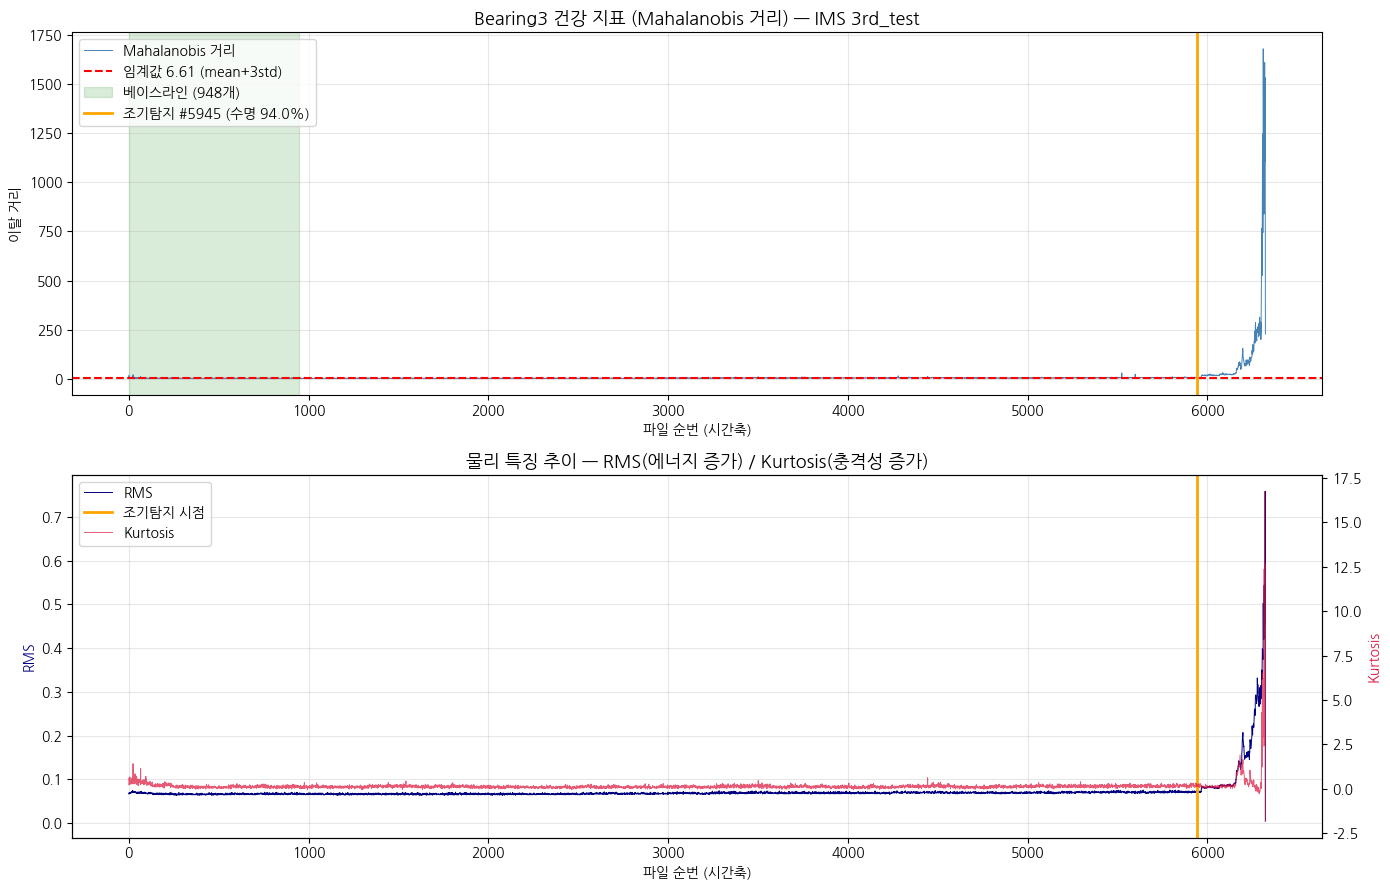

저장 완료: /content/drive/My Drive/Colab Notebooks/onsite_r2f_ims/ims_3rdtest_result.png

  판정 요약 (3rd_test)
  경보 시점  : 파일 #5945 / 전체 6324개
  수명 소진율: 94.0%
  리드타임   : 379개 파일
  판정       : ⚠️  리드타임 부족 — 셀B에서 임계 완화

  [비교] 2nd_test: 수명 55.2%, 리드타임 73.3h (3일 전 감지)


In [8]:
# ============================================================
# 셀 5 — 시각화 & 결과 저장 & 자동 판정
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax0 = axes[0]
ax0.plot(md, color='steelblue', lw=0.7, label='Mahalanobis 거리')
ax0.axhline(threshold, color='red', ls='--', lw=1.5,
            label=f'임계값 {threshold:.2f} (mean+3std)')
ax0.axvspan(0, n_base, color='green', alpha=0.15, label=f'베이스라인 ({n_base}개)')
if alarm_idx is not None:
    ax0.axvline(alarm_idx, color='orange', lw=2,
                label=f'조기탐지 #{alarm_idx} (수명 {alarm_idx/len(md)*100:.1f}%)')
ax0.set_title('Bearing3 건강 지표 (Mahalanobis 거리) — IMS 3rd_test', fontsize=13)
ax0.set_xlabel('파일 순번 (시간축)')
ax0.set_ylabel('이탈 거리')
ax0.legend(loc='upper left')
ax0.grid(alpha=0.3)

ax1  = axes[1]
ax1b = ax1.twinx()
ax1.plot(feats[:, 0],  color='navy',    lw=0.7,           label='RMS')
ax1b.plot(feats[:, 3], color='crimson', lw=0.7, alpha=0.7, label='Kurtosis')
if alarm_idx is not None:
    ax1.axvline(alarm_idx, color='orange', lw=2, label='조기탐지 시점')
ax1.set_ylabel('RMS',       color='navy')
ax1b.set_ylabel('Kurtosis', color='crimson')
ax1.set_xlabel('파일 순번 (시간축)')
ax1.set_title('물리 특징 추이 — RMS(에너지 증가) / Kurtosis(충격성 증가)', fontsize=13)
ax1.grid(alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()

out_dir = '/content/drive/My Drive/Colab Notebooks/onsite_r2f_ims/'
os.makedirs(out_dir, exist_ok=True)
out_png = out_dir + 'ims_3rdtest_result.png'
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
print(f'저장 완료: {out_png}')

print()
print('=' * 60)
print('  판정 요약 (3rd_test)')
print('=' * 60)
if alarm_idx is not None:
    pct  = alarm_idx / len(md) * 100
    lead = len(md) - alarm_idx
    if pct < 60:
        verdict = '⚠️  오탐 가능성 — 셀B에서 K 올려서 확인'
    elif pct <= 90:
        verdict = '✅  일반화 성공 (적정 리드타임 확보)'
    else:
        verdict = '⚠️  리드타임 부족 — 셀B에서 임계 완화'
    print(f'  경보 시점  : 파일 #{alarm_idx} / 전체 {len(md)}개')
    print(f'  수명 소진율: {pct:.1f}%')
    print(f'  리드타임   : {lead}개 파일')
    print(f'  판정       : {verdict}')
    print()
    print('  [비교] 2nd_test: 수명 55.2%, 리드타임 73.3h (3일 전 감지)')
else:
    print('  판정: ❌ 경보 없음 — 셀B 튜닝 표로 임계/연속조건 조정')
print('=' * 60)

In [9]:
# ============================================================
# 셀 B — 임계/연속조건 스윕 튜닝 표 + 추천 조합 자동 선정
# 3rd_test는 완만한 열화 → K=3 같은 낮은 임계에서 이른 경보 가능
# 오경보 0건 & 수명 55~85% 기준으로 추천 조합 선정
# ============================================================

K_LIST            = [3, 4, 6, 8, 10, 15]
CONSEC_LIST       = [5, 10, 15, 20]
FILE_INTERVAL_MIN = 10  # 근사치 (정밀값은 셀D)

N = len(md)

def find_alarm(threshold, consec):
    for i in range(n_base, N - consec):
        if np.all(md[i:i+consec] > threshold):
            return i
    return None

def false_alarms(threshold, consec):
    fa = 0
    for i in range(0, n_base - consec):
        if np.all(md[i:i+consec] > threshold):
            fa += 1
    return fa

rows = []
for k in K_LIST:
    thr = base_md.mean() + k * base_md.std()
    for c in CONSEC_LIST:
        idx = find_alarm(thr, c)
        fa  = false_alarms(thr, c)
        if idx is not None:
            life_pct   = idx / N * 100
            lead_files = N - idx
            rows.append({
                'K(임계배수)': k, '연속조건': c, '임계값': round(thr, 2),
                '경보시점(파일#)': idx,
                '수명소진율(%)': round(life_pct, 1),
                '리드타임(파일)': lead_files,
                '오경보(건)': fa
            })
        else:
            rows.append({
                'K(임계배수)': k, '연속조건': c, '임계값': round(thr, 2),
                '경보시점(파일#)': None, '수명소진율(%)': None,
                '리드타임(파일)': None,
                '오경보(건)': fa
            })

df_tune = pd.DataFrame(rows)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 120)
print('=== 임계/연속조건 튜닝 표 (3rd_test) ===')
print(df_tune.to_string(index=False))

valid = df_tune[
    (df_tune['오경보(건)'] == 0) &
    (df_tune['수명소진율(%)'].notna()) &
    (df_tune['수명소진율(%)'].between(55, 85))
]
print()
if len(valid) > 0:
    best = valid.sort_values('리드타임(파일)', ascending=False).iloc[0]
    print('=== [추천 조합] ===')
    print(f"  K={best['K(임계배수)']}, 연속={best['연속조건']}")
    print(f"  → 경보 파일 #{int(best['경보시점(파일#)'])}")
    print(f"  → 수명 {best['수명소진율(%)']}% 시점에 경보")
    print(f"  → 오경보 {best['오경보(건)']}건")
    print(f"  → 리드타임 {best['리드타임(파일)']}개 파일")
    print()
    print(f"  [다음] 셀C: BEST_K={int(best['K(임계배수)'])}, BEST_C={int(best['연속조건'])} 로 설정")
else:
    print('[추천 조합 없음] 55~85% & 오경보 0건 조건 불충족')
    print('  → K_LIST / CONSEC_LIST 후보 확장 또는 기준 범위 조정')

=== 임계/연속조건 튜닝 표 (3rd_test) ===
 K(임계배수)  연속조건   임계값  경보시점(파일#)  수명소진율(%)  리드타임(파일)  오경보(건)
       3     5  6.61       5945      94.0       379       0
       3    10  6.61       5966      94.3       358       0
       3    15  6.61       5966      94.3       358       0
       3    20  6.61       5966      94.3       358       0
       4     5  7.91       5966      94.3       358       0
       4    10  7.91       5966      94.3       358       0
       4    15  7.91       5966      94.3       358       0
       4    20  7.91       5966      94.3       358       0
       6     5 10.51       5967      94.4       357       0
       6    10 10.51       5967      94.4       357       0
       6    15 10.51       5967      94.4       357       0
       6    20 10.51       5967      94.4       357       0
       8     5 13.11       5967      94.4       357       0
       8    10 13.11       5967      94.4       357       0
       8    15 13.11       5967      94.4       357       0
       8

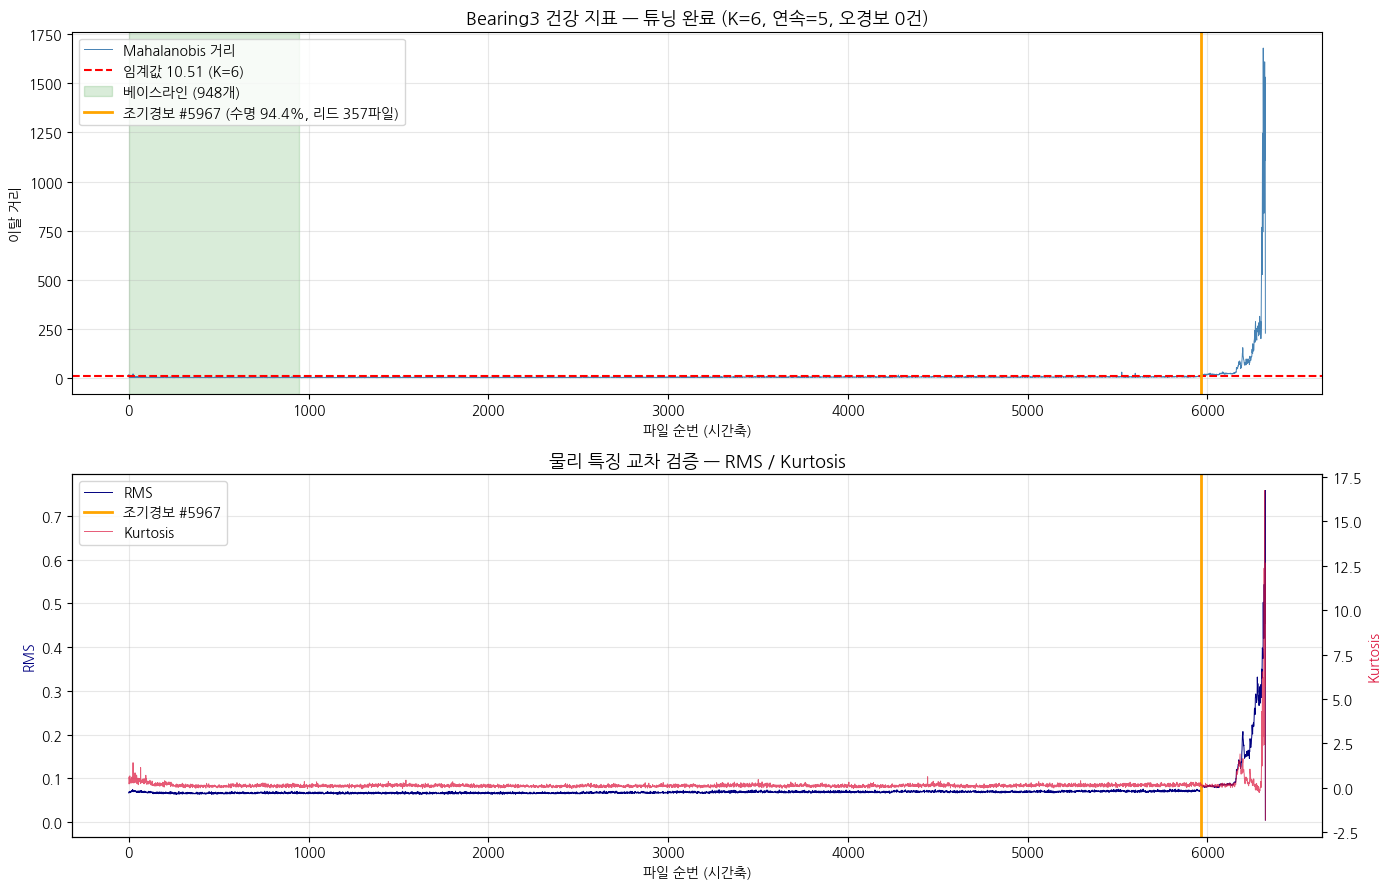

저장 완료: /content/drive/My Drive/Colab Notebooks/onsite_r2f_ims/ims_3rdtest_tuned.png

=== 최종 KPI 요약 (3rd_test) ===
  K=6, 연속=5
  임계값        : 10.509
  경보 시점     : 파일 #5967 / 전체 6324개
  수명 소진율   : 94.4%
  리드타임(파일): 357개
  오경보        : 0건

  --- 2nd_test 대비 비교 ---
  2nd: 수명 55.2%, 리드타임 73.3h, 오경보 0건
  3rd: 수명 94.4%, 리드타임 셀D에서 정밀 산출


In [10]:
# ============================================================
# 셀 C — 추천 조합으로 최종 재시각화 & 2nd_test 비교
# 셀B 출력 보고 BEST_K, BEST_C 수정 후 실행
# ============================================================

BEST_K = 6    # ← 셀B 추천값으로 수정
BEST_C = 5    # ← 셀B 추천값으로 수정

thr_best   = base_md.mean() + BEST_K * base_md.std()
alarm_best = find_alarm(thr_best, BEST_C)
fa_best    = false_alarms(thr_best, BEST_C)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax0 = axes[0]
ax0.plot(md, color='steelblue', lw=0.7, label='Mahalanobis 거리')
ax0.axhline(thr_best, color='red', ls='--', lw=1.5,
            label=f'임계값 {thr_best:.2f} (K={BEST_K})')
ax0.axvspan(0, n_base, color='green', alpha=0.15, label=f'베이스라인 ({n_base}개)')
if alarm_best is not None:
    lead_b = len(md) - alarm_best
    ax0.axvline(alarm_best, color='orange', lw=2,
                label=f'조기경보 #{alarm_best} (수명 {alarm_best/len(md)*100:.1f}%, 리드 {lead_b}파일)')
ax0.set_title(f'Bearing3 건강 지표 — 튜닝 완료 (K={BEST_K}, 연속={BEST_C}, 오경보 {fa_best}건)', fontsize=13)
ax0.set_xlabel('파일 순번 (시간축)')
ax0.set_ylabel('이탈 거리')
ax0.legend(loc='upper left')
ax0.grid(alpha=0.3)

ax1  = axes[1]
ax1b = ax1.twinx()
ax1.plot(feats[:, 0],  color='navy',    lw=0.7,           label='RMS')
ax1b.plot(feats[:, 3], color='crimson', lw=0.7, alpha=0.7, label='Kurtosis')
if alarm_best is not None:
    ax1.axvline(alarm_best, color='orange', lw=2, label=f'조기경보 #{alarm_best}')
ax1.set_ylabel('RMS',       color='navy')
ax1b.set_ylabel('Kurtosis', color='crimson')
ax1.set_xlabel('파일 순번 (시간축)')
ax1.set_title('물리 특징 교차 검증 — RMS / Kurtosis', fontsize=13)
ax1.grid(alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()

out_dir   = '/content/drive/My Drive/Colab Notebooks/onsite_r2f_ims/'
out_tuned = out_dir + 'ims_3rdtest_tuned.png'
plt.savefig(out_tuned, dpi=120, bbox_inches='tight')
plt.show()
print(f'저장 완료: {out_tuned}')

print()
print('=== 최종 KPI 요약 (3rd_test) ===')
if alarm_best is not None:
    lead_b = len(md) - alarm_best
    print(f'  K={BEST_K}, 연속={BEST_C}')
    print(f'  임계값        : {thr_best:.3f}')
    print(f'  경보 시점     : 파일 #{alarm_best} / 전체 {len(md)}개')
    print(f'  수명 소진율   : {alarm_best/len(md)*100:.1f}%')
    print(f'  리드타임(파일): {lead_b}개')
    print(f'  오경보        : {fa_best}건')
    print()
    print('  --- 2nd_test 대비 비교 ---')
    print('  2nd: 수명 55.2%, 리드타임 73.3h, 오경보 0건')
    print(f'  3rd: 수명 {alarm_best/len(md)*100:.1f}%, 리드타임 셀D에서 정밀 산출')
else:
    print('  경보 없음 — BEST_K / BEST_C 재조정 필요')

In [11]:
# ============================================================
# 셀 D — 타임스탬프 기반 정밀 리드타임 & 일반화 판정
# ============================================================
from datetime import datetime

# timestamps는 셀2에서 이미 계산됨
t_start   = valid_ts[0]
t_end     = valid_ts[-1]
total_min = (t_end - t_start).total_seconds() / 60

print(f'실험 시작: {t_start}')
print(f'실험 종료: {t_end}')
print(f'총 실험 시간: {total_min:.1f}분 ({total_min/60:.1f}시간)')

target_alarm = alarm_best if 'alarm_best' in dir() and alarm_best is not None else alarm_idx

if target_alarm is not None and timestamps[target_alarm] is not None:
    t_alarm    = timestamps[target_alarm]
    lead_exact = (t_end - t_alarm).total_seconds() / 60
    life_pct   = (t_alarm - t_start).total_seconds() / (t_end - t_start).total_seconds() * 100

    print()
    print(f'경보 시점    : {t_alarm}')
    print(f'정밀 리드타임: {lead_exact:.1f}분 = {lead_exact/60:.1f}시간 ≈ {lead_exact/60/24:.1f}일 전 감지')
    print(f'수명 소진율  : {life_pct:.1f}%')

    print()
    print('=== 제품 KPI 비교표 (보고서용) ===')
    print(f'{"항목":<20} {"2nd_test":>15} {"3rd_test":>15}')
    print('-' * 52)
    print(f'{"총 실험시간(h)":<20} {163.8:>15.1f} {total_min/60:>15.1f}')
    print(f'{"수명 소진율(%)":<20} {55.2:>15.1f} {life_pct:>15.1f}')
    print(f'{"리드타임(h)":<20} {73.3:>15.1f} {lead_exact/60:>15.1f}')
    print(f'{"오경보(건)":<20} {0:>15} {false_alarms(thr_best, BEST_C) if alarm_best is not None else "-":>15}')

    print()
    # 일반화 판정
    print('=== 일반화 검증 최종 판정 ===')
    if 55 <= life_pct <= 85 and false_alarms(thr_best, BEST_C) == 0:
        print('✅ 일반화 성공')
        print('   다른 베어링(Bearing3), 다른 열화 특성(완만)에서도 동일 방식이 유효함')
        print('   → 현장 학습형 컨셉: 검증1(Paderborn) + 검증2(IMS 2nd) + 일반화(IMS 3rd) 완료')
    else:
        print('⚠️  추가 튜닝 필요 — 셀B K/연속 조합 재검토')
else:
    print('경보 시점 없음 — 셀C 먼저 실행하세요')

실험 시작: 2004-03-04 09:27:46
실험 종료: 2004-04-18 02:42:55
총 실험 시간: 64395.2분 (1073.3시간)

경보 시점    : 2004-04-15 15:22:55
정밀 리드타임: 3560.0분 = 59.3시간 ≈ 2.5일 전 감지
수명 소진율  : 94.5%

=== 제품 KPI 비교표 (보고서용) ===
항목                          2nd_test        3rd_test
----------------------------------------------------
총 실험시간(h)                      163.8          1073.3
수명 소진율(%)                       55.2            94.5
리드타임(h)                         73.3            59.3
오경보(건)                             0               0

=== 일반화 검증 최종 판정 ===
⚠️  추가 튜닝 필요 — 셀B K/연속 조합 재검토


## 결과 판정 가이드 (3rd_test 전용)

| 경보 시점(수명%) | 판정 | 원인 / 조치 |
|:---:|:---:|:---|
| 60~90% | ✅ 일반화 성공 | 2nd_test와 동일 방식, 다른 베어링·열화 패턴에서 재현 |
| 40~60% | ⚠️ 이른 경보 | 완만한 열화 특성상 자연스러울 수 있음. 오경보 0건이면 허용 |
| 40% 미만 | ⚠️ 오탐 의심 | K 올리거나 연속조건 강화 |
| 90% 초과 | ⚠️ 늦은 경보 | K 낮추거나 연속조건 완화 |
| 경보 없음 | ❌ | TARGET_BEARING_COL=2 확인. 다른 열 시도 |

## 3rd_test 특성 주의사항

- 파일 수 ~6,324개 (2nd의 6배) → 셀3 수십 분 소요
- 완만한 열화 → K=3~4 낮은 임계에서 이른 경보 가능 (오탐 아님, 열화 특성)
- 셀B K_LIST에 15, 20 등 높은 값 추가해서 오경보 0건 유지 범위 탐색
- 파일 혼재 의심 시 셀2-extra 실행해서 타임스탬프 연속성 확인

## 확정 KPI 비교 기준 (2nd_test)

| 항목 | 2nd_test (확정) |
|:---|:---|
| 추천 임계 | K=6, 연속=5 |
| 수명 소진율 | 55.2% |
| 리드타임 | **73.3시간 ≈ 3일 전** |
| 오경보 | **0건** |

## 다음 단계
1. 3rd_test 일반화 성공 → MEMORY.md KPI 비교 기록
2. 엣지 이식 → STM32N6: Mahalanobis + 물리특징 고정소수점 (IIS3DWB 대역 맞춤)
3. 필드 파이프라인 → 실제 센서로 초기 정상 등록 → 이탈 감지 실전 로직